In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv('../dataset/paysim_data.csv', nrows=500000)

# FIX: PaySim has no 'hour' column — we derive it from 'step'
# step is hours since simulation start, so step % 24 = hour of day
df['hour'] = df['step'] % 24
df['day']  = df['step'] // 24

print("Data loaded and hour column created ✅")
print(df[['step', 'hour', 'day']].head(3))

Data loaded and hour column created ✅
   step  hour  day
0     1     1    0
1     1     1    0
2     1     1    0


C:\Users\rohan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128336 (\N{CLOCK FACE ONE OCLOCK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


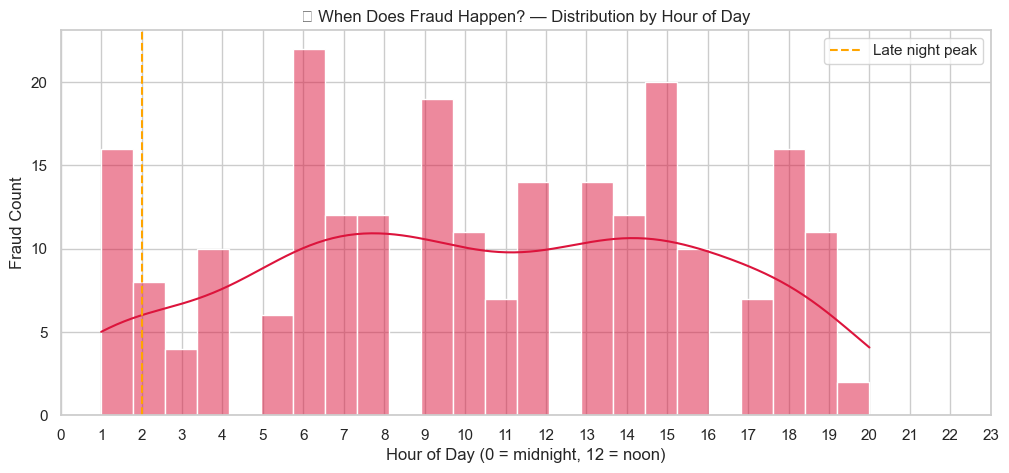

In [3]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df[df['isFraud'] == 1], x='hour', bins=24, color='crimson', kde=True)
plt.title('🕐 When Does Fraud Happen? — Distribution by Hour of Day')
plt.xlabel('Hour of Day (0 = midnight, 12 = noon)')
plt.ylabel('Fraud Count')
plt.xticks(range(0, 24))
plt.axvline(x=2, color='orange', linestyle='--', label='Late night peak')
plt.legend()
plt.show()

# KEY INSIGHT: Fraud spikes at certain hours
# This validates our "Midnight Ghost" scenario — late night = higher risk

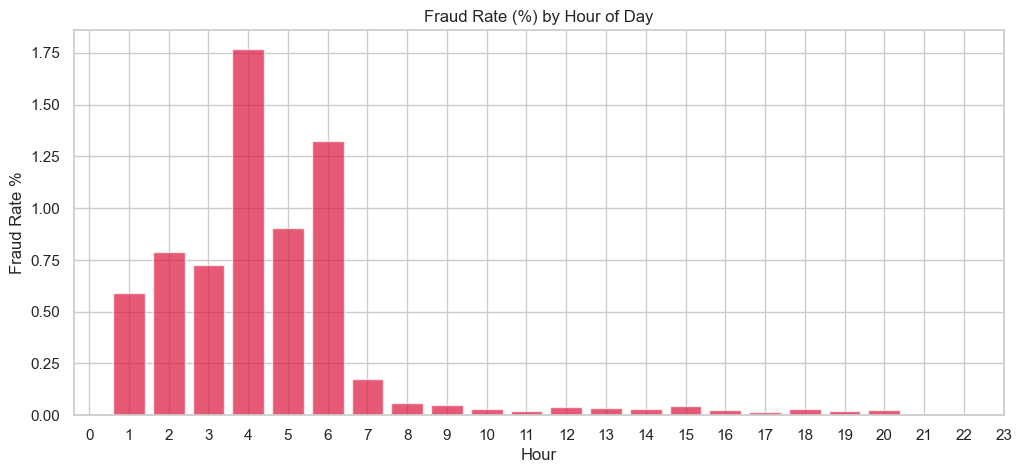

In [4]:
# Raw count is misleading — fewer transactions happen at 3am overall
# Fraud RATE tells a better story
hourly = df.groupby('hour').agg(
    total_tx    = ('isFraud', 'count'),
    fraud_tx    = ('isFraud', 'sum')
).reset_index()
hourly['fraud_rate'] = hourly['fraud_tx'] / hourly['total_tx'] * 100

plt.figure(figsize=(12, 5))
plt.bar(hourly['hour'], hourly['fraud_rate'], color='crimson', alpha=0.7)
plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate %')
plt.xticks(range(0, 24))
plt.show()

Risk transactions: 223,046 out of 500,000
Fraud in risk set: 233


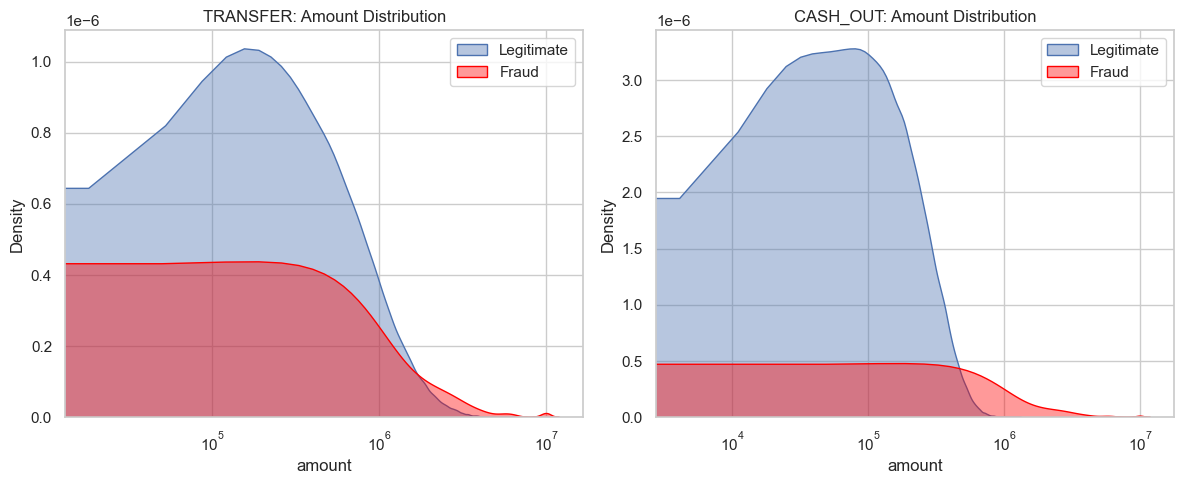

In [5]:
# Since fraud ONLY appears in these 2 types, filter to them
df_risk = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print(f"Risk transactions: {len(df_risk):,} out of {len(df):,}")
print(f"Fraud in risk set: {df_risk['isFraud'].sum():,}")

# Compare amount patterns
plt.figure(figsize=(12, 5))
for i, txtype in enumerate(['TRANSFER', 'CASH_OUT']):
    subset = df_risk[df_risk['type'] == txtype]
    plt.subplot(1, 2, i+1)
    sns.kdeplot(data=subset[subset['isFraud']==0], x='amount', label='Legitimate', fill=True, alpha=0.4)
    sns.kdeplot(data=subset[subset['isFraud']==1], x='amount', label='Fraud', fill=True, alpha=0.4, color='red')
    plt.xscale('log')
    plt.title(f'{txtype}: Amount Distribution')
    plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# KEY INSIGHT from PaySim documentation:
# In fraud transactions, the sender's balance often doesn't change correctly
# (a bug in the simulation that actually mirrors real fraud!)
# balance_change_error = oldbalanceOrg - amount - newbalanceOrig
# If this isn't ~0, something is wrong

df_risk['balance_error_orig'] = (
    df_risk['oldbalanceOrg'] - df_risk['amount'] - df_risk['newbalanceOrig']
).abs()

print("Balance error — Legitimate transactions:")
print(df_risk[df_risk['isFraud']==0]['balance_error_orig'].describe())

print("\nBalance error — Fraud transactions:")
print(df_risk[df_risk['isFraud']==1]['balance_error_orig'].describe())

# Fraud has much higher balance errors — this will be a key feature

Balance error — Legitimate transactions:
count    2.228130e+05
mean     2.432731e+05
std      3.467420e+05
min      0.000000e+00
25%      5.071509e+04
50%      1.486297e+05
75%      2.926962e+05
max      6.388051e+06
Name: balance_error_orig, dtype: float64

Balance error — Fraud transactions:
count    2.330000e+02
mean     2.528156e+04
std      1.563982e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.933921e+06
Name: balance_error_orig, dtype: float64


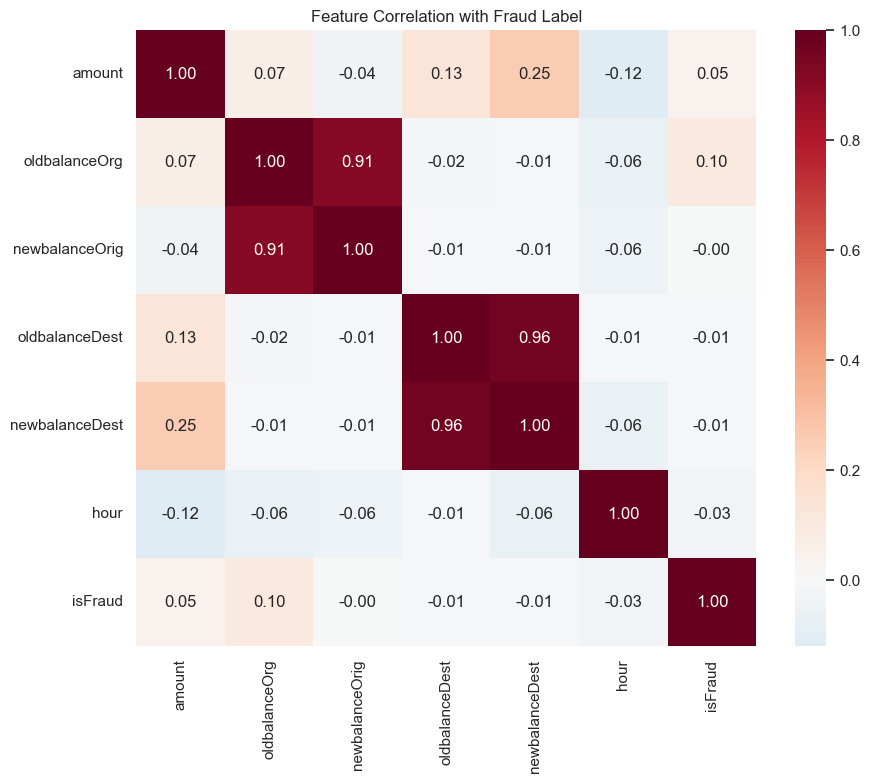

In [7]:
# Numeric columns only for correlation
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest', 'hour', 'isFraud']
plt.figure(figsize=(10, 8))
sns.heatmap(df_risk[num_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature Correlation with Fraud Label')
plt.show()

In [8]:
print("""
╔══════════════════════════════════════════════════════╗
║           EDA KEY FINDINGS FOR FEATURE ENGINEERING   ║
╠══════════════════════════════════════════════════════╣
║  1. Fraud ONLY in TRANSFER + CASH_OUT → filter first ║
║  2. Fraud amounts tend to be LARGER                  ║
║  3. Balance errors are higher in fraud rows          ║
║  4. Hour of day matters — late night spikes          ║
║  5. Dataset is ~0.12% fraud → IMBALANCED             ║
║     → Use AUC-PR, not accuracy, as metric            ║
║     → Use scale_pos_weight in XGBoost                ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║           EDA KEY FINDINGS FOR FEATURE ENGINEERING   ║
╠══════════════════════════════════════════════════════╣
║  1. Fraud ONLY in TRANSFER + CASH_OUT → filter first ║
║  2. Fraud amounts tend to be LARGER                  ║
║  3. Balance errors are higher in fraud rows          ║
║  4. Hour of day matters — late night spikes          ║
║  5. Dataset is ~0.12% fraud → IMBALANCED             ║
║     → Use AUC-PR, not accuracy, as metric            ║
║     → Use scale_pos_weight in XGBoost                ║
╚══════════════════════════════════════════════════════╝

